# Three Stage Model

1. Classification step 1: Carbon or Nitrogen (binary)
2. Classification step 2: Which carbon or which nitrogen source (multiclass)
3. Regression: Predict uptake of present nutrients

*previous implementations have revealed that the model is essentially just predicting 0/absence because targets are zero-inflated*

In [108]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.express as px

In [184]:
# from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

# Loss metric:
from sklearn.metrics import mean_squared_error as mse

# evaluation:
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import confusion_matrix, accuracy_score, multilabel_confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# data prep and plotting etc:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

### Load Data

In [111]:
train_data = pd.read_pickle(DATA/"ml_datasets/TRAIN_raw.pkl")
features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_ML.pkl")

rxn_cols = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e','EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

In [112]:
target = train_data[rxn_cols]
target = (-target.clip(upper=0))
target[target == 0] = 0 # to avoid negative

target['source'] = train_data['source']
target['source_type'] = target['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

**SPLIT -> TRAIN AND VALIDATION**

In [113]:
X = features.copy()
Y = target.copy()

In [114]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

### Target distribution

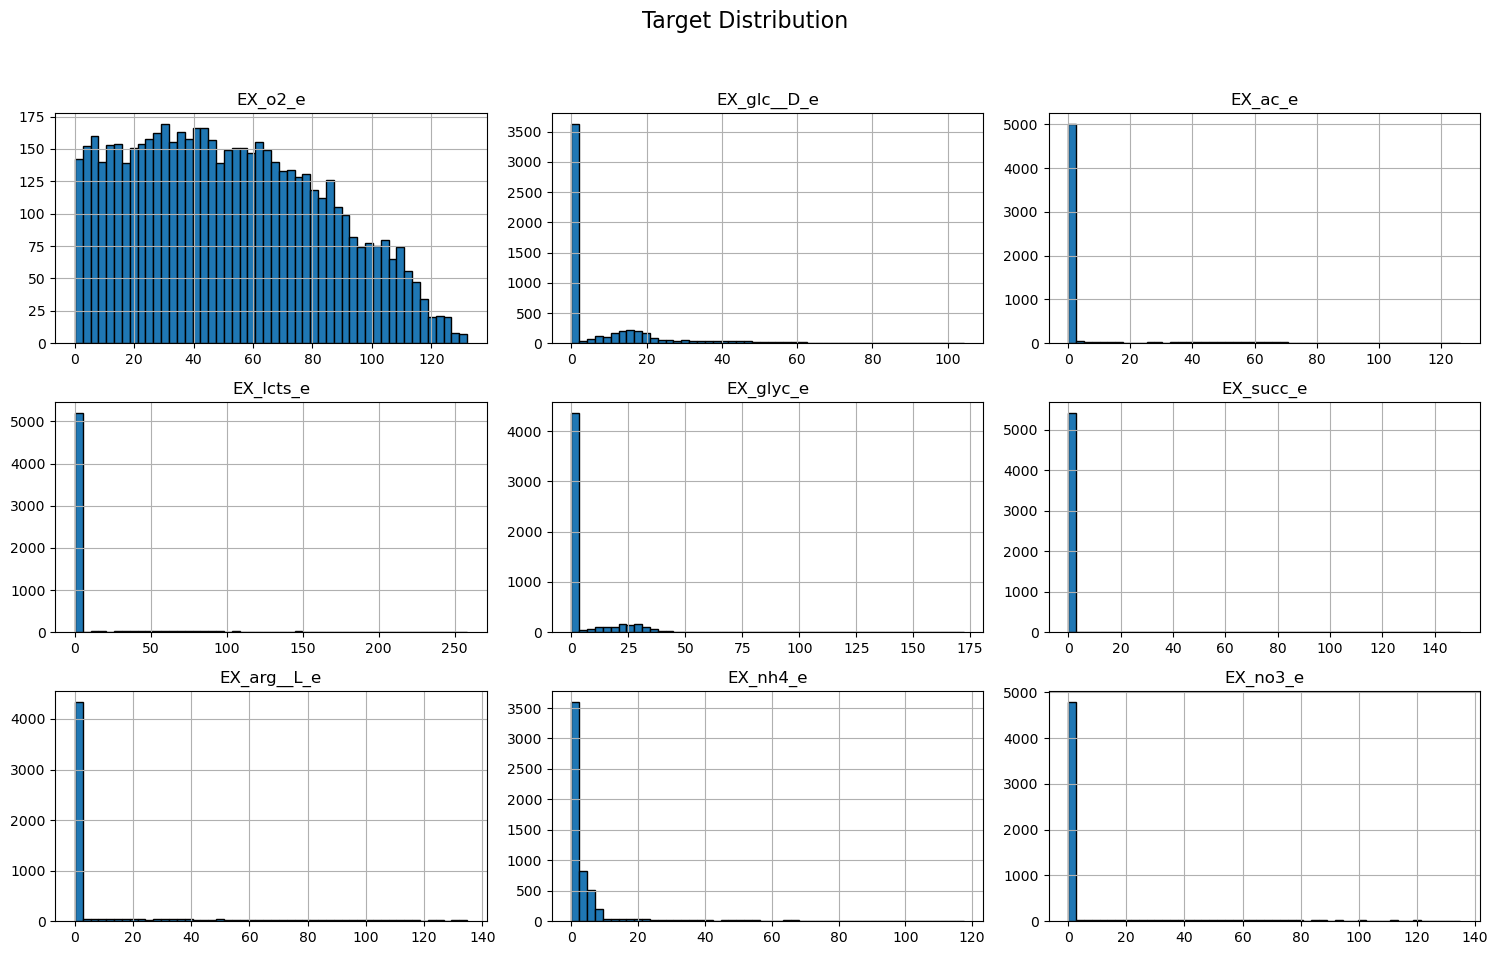

In [115]:
target.iloc[:, :9].hist(bins=50, figsize=(15, 10), layout=(-1, 3), edgecolor='black')

plt.suptitle('Target Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

## 1.1 - Defining Targets for Each Stage

In [116]:
Y_train_type = Y_train['source_type']
Y_val_type = Y_val['source_type']

le_type = LabelEncoder()
Y_train_type = le_type.fit_transform(Y_train_type)
Y_val_type = le_type.transform(Y_val_type)

##################################################
Y_train_num = Y_train.iloc[:, :9]
Y_val_num = Y_val.iloc[:, :9]

**For separate source-specific classifiers:**

In [117]:
# Stage 2: specific source
Y_train_source = Y_train['source']
Y_val_source = Y_val['source']


c_mask_train = (Y_train['source_type'] == "carbon")
c_mask_val = (Y_val['source_type'] == "carbon")
n_mask_train = (Y_train['source_type'] == "nitrogen")
n_mask_val = (Y_val['source_type'] == "nitrogen")

# subset X
X_train_c = X_train[c_mask_train]
X_val_c = X_val[c_mask_val]
X_train_n = X_train[n_mask_train]
X_val_n = X_val[n_mask_val]

# subset source labels
Y_train_c = Y_train_source[c_mask_train]
Y_val_c = Y_val_source[c_mask_val]
Y_train_n = Y_train_source[n_mask_train]
Y_val_n = Y_val_source[n_mask_val]

le_carbon = LabelEncoder()
le_nitrogen = LabelEncoder()

Y_train_c_enc = le_carbon.fit_transform(Y_train_c)
Y_val_c_enc = le_carbon.transform(Y_val_c)

Y_train_n_enc = le_nitrogen.fit_transform(Y_train_n)
Y_val_n_enc = le_nitrogen.transform(Y_val_n)

## 2. - Training Each Model

### 2.1 - Type Classifier (Carbon or Nitrogen)

In [118]:
binary_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

binary_clf.fit(X_train, Y_train_type)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 2.2 - Source Classifiers

In [119]:
carbon_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

nitrogen_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

carbon_clf.fit(X_train_c, Y_train_c_enc)
nitrogen_clf.fit(X_train_n, Y_train_n_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 2.3 - Regressors

**BASELINE**

In [121]:
baseline_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )
)

baseline_reg.fit(X_train, Y_train_num)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least o

**HURDLE**

*separate regressor for carbon and nitrogen sources*

In [122]:
carbon_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )
)

nitrogen_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )
)


carbon_reg.fit(X_train_c, Y_train_num[c_mask_train])
nitrogen_reg.fit(X_train_n, Y_train_num[n_mask_train])

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least o

**GLOBAL REGRESSOR**

In [175]:
# STAGE 1 (Carbon or Nitrogen):
binary_proba_train = binary_clf.predict_proba(X_train)

# STAGE 2 (WHICH CARBON OR WHICH NITROGEN):
n_train = len(X_train)
carbon_proba_train = np.zeros((n_train, len(le_carbon.classes_)))
nitrogen_proba_train = np.zeros((n_train, len(le_nitrogen.classes_)))

carbon_label = le_type.transform(["carbon"])[0]
nitrogen_label = le_type.transform(["nitrogen"])[0]

carbon_mask_train = c_mask_train.to_numpy()
nitrogen_mask_train = n_mask_train.to_numpy()

carbon_proba_train[carbon_mask_train] = carbon_clf.predict_proba(X_train.iloc[carbon_mask_train])
nitrogen_proba_train[nitrogen_mask_train] = nitrogen_clf.predict_proba(X_train.iloc[nitrogen_mask_train])

X_train_global = np.hstack([X_train, binary_proba_train, carbon_proba_train, nitrogen_proba_train])

In [176]:
global_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )
)

global_reg.fit(X_train_global, Y_train_num)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least o

## 3 - Predict

### Hurdle 1:

In [ ]:
def make_prediction(X):
    binary_pred = binary_clf.predict(X) # C or N

    source_pred = np.empty(len(X), dtype=object) #placeholder for source_type classification
    uptake_pred = np.zeros((len(X), Y_train_num.shape[1])) #placeholder for regression
    
    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    if len(carbon_idx) > 0:
        X_c = X.iloc[carbon_idx]
        source_pred[carbon_idx] = carbon_clf.predict(X_c)
        uptake_pred[carbon_idx] = carbon_reg.predict(X_c)
    
    if len(nitrogen_idx) > 0:
        X_n = X.iloc[nitrogen_idx]
        source_pred[nitrogen_idx] = nitrogen_clf.predict(X_n)
        uptake_pred[nitrogen_idx] = nitrogen_reg.predict(X_n)

    return binary_pred, source_pred, uptake_pred

In [124]:
binary_pred_val, source_pred_val, uptake_pred_val = make_prediction(X_val)

### Hurdle 2:

In [164]:
# def make_prediction2(X):
#     proba = binary_clf.predict_proba(X)

#     carbon_label = le_type.transform(["carbon"])[0]
#     nitrogen_label = le_type.transform(["nitrogen"])[0]

#     carbon_idx_col = list(binary_clf.classes_).index(carbon_label)
#     nitrogen_idx_col = list(binary_clf.classes_).index(nitrogen_label)

#     carbon_proba = proba[:, carbon_idx_col]
#     nitrogen_proba = proba[:, nitrogen_idx_col]

#     source_pred = np.empty(len(X), dtype=object)
#     uptake_pred = np.zeros((len(X), Y_train_num.shape[1]))
    
#     X_c = X
#     carbon_source_pred = carbon_clf.predict(X_c)
#     carbon_uptake_pred = carbon_reg.predict(X_c)
    
#     X_n = X
#     nitrogen_source_pred= nitrogen_clf.predict(X_n)
#     nitrogen_uptake_pred = nitrogen_reg.predict(X_n)

#     uptake_pred += carbon_proba[:, None] * carbon_uptake_pred
#     uptake_pred += nitrogen_proba[:, None] * nitrogen_uptake_pred

#     # optional: still assign source based on max prob (for interpretability)
#     binary_pred = binary_clf.predict(X)
#     carbon_idx = np.where(binary_pred == carbon_label)[0]
#     nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

#     source_pred[carbon_idx] = carbon_source_pred[carbon_idx]
#     source_pred[nitrogen_idx] = nitrogen_source_pred[nitrogen_idx]

#     return binary_pred, source_pred, uptake_pred

In [178]:
def make_prediction2(X):
    binary_proba = binary_clf.predict_proba(X)

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx_col = list(binary_clf.classes_).index(carbon_label)
    nitrogen_idx_col = list(binary_clf.classes_).index(nitrogen_label)

    binary_pred = binary_clf.predict(X)

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
    nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

    if len(carbon_idx) > 0:
        carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

    X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])
    

    uptake_pred = global_reg.predict(X_global)

    source_pred = np.empty(len(X), dtype=object)
    if len(carbon_idx) > 0:
        source_pred[carbon_idx] = carbon_clf.predict(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = nitrogen_clf.predict(X.iloc[nitrogen_idx])

    return binary_pred, source_pred, uptake_pred

In [179]:
binary_pred_val2, source_pred_val2, uptake_pred_val2 = make_prediction2(X_val)

## 4 - Model Evaluation

### Hurdle 1:

**Stage 1: Carbon vs Nitrogen**

In [207]:
print(classification_report(Y_val_type, binary_pred_val, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.88      0.77      0.82       490
    nitrogen       0.85      0.92      0.88       672

    accuracy                           0.86      1162
   macro avg       0.86      0.85      0.85      1162
weighted avg       0.86      0.86      0.86      1162



**Stage 2: Source**

In [128]:
print(classification_report(Y_val_c_enc, carbon_clf.predict(X_val_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.82      0.88      0.85        77
         glc       0.80      0.74      0.77       112
        glyc       0.82      0.54      0.65        93
        lcts       0.68      0.93      0.79       126
        succ       0.94      0.80      0.87        82

    accuracy                           0.78       490
   macro avg       0.81      0.78      0.78       490
weighted avg       0.80      0.78      0.78       490



In [129]:
print(classification_report(Y_val_n_enc, nitrogen_clf.predict(X_val_n), target_names=le_nitrogen.classes_, zero_division=0))

              precision    recall  f1-score   support

      arg_ac       0.62      0.77      0.69        93
     arg_glc       0.65      0.67      0.66       107
    arg_glyc       0.72      0.70      0.71       104
      nh4_ac       0.80      0.68      0.74        47
     nh4_glc       0.85      0.92      0.88       110
      no3_ac       0.00      0.00      0.00         6
     no3_glc       0.75      0.75      0.75       110
    no3_glyc       0.85      0.67      0.75        95

    accuracy                           0.74       672
   macro avg       0.66      0.65      0.65       672
weighted avg       0.74      0.74      0.74       672



**Stage 3: Regression**

* Hurdle:

In [130]:
rmse_per_output = rmse(Y_val_num, uptake_pred_val, multioutput='raw_values')
mae_per_output = mae(Y_val_num, uptake_pred_val, multioutput='raw_values')
r2_per_output = r2_score(Y_val_num, uptake_pred_val, multioutput='raw_values')

for col, r, m, r2 in zip(Y_val_num.columns, rmse_per_output, mae_per_output, r2_per_output):
    print(f"{col:<20} RMSE: {r:>8.3f}   MAE: {m:>8.3f}   R²:{r2:>8.3f}")

EX_o2_e              RMSE:   14.291   MAE:    9.801   R²:   0.784
EX_glc__D_e          RMSE:    8.091   MAE:    5.041   R²:   0.762
EX_ac_e              RMSE:   16.960   MAE:    6.138   R²:   0.302
EX_lcts_e            RMSE:   20.253   MAE:    6.372   R²:   0.564
EX_glyc_e            RMSE:   23.371   MAE:   10.152   R²:   0.247
EX_succ_e            RMSE:    6.226   MAE:    1.234   R²:   0.909
EX_arg__L_e          RMSE:   16.693   MAE:    7.294   R²:   0.701
EX_nh4_e             RMSE:    6.941   MAE:    2.738   R²:   0.836
EX_no3_e             RMSE:    8.112   MAE:    3.042   R²:   0.906


In [131]:
for i, col in enumerate(Y_val_num.columns):
    y_true = Y_val_num.iloc[:, i].values
    y_pred = uptake_pred_val[:, i]

    mask = y_true > 0

    if mask.sum() < 2:
        print(f"{col:<20} Not enough positive samples")
        continue

    rmse_val = rmse(y_true[mask], y_pred[mask])
    mae_val = mae(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"{col:<20} RMSE: {rmse_val:>8.3f}   MAE: {mae_val:>8.3f}   R²:{r2_val:>8.3f}")

EX_o2_e              RMSE:   14.291   MAE:    9.801   R²:   0.784
EX_glc__D_e          RMSE:    9.995   MAE:    7.073   R²:   0.721
EX_ac_e              RMSE:   41.479   MAE:   29.716   R²:  -0.603
EX_lcts_e            RMSE:   39.946   MAE:   26.424   R²:   0.406
EX_glyc_e            RMSE:   44.439   MAE:   25.105   R²:  -0.256
EX_succ_e            RMSE:   21.317   MAE:   12.005   R²:   0.758
EX_arg__L_e          RMSE:   21.076   MAE:   13.649   R²:   0.665
EX_nh4_e             RMSE:    8.217   MAE:    3.551   R²:   0.854
EX_no3_e             RMSE:   10.066   MAE:    6.819   R²:   0.918


**VERSION 2**

In [180]:
rmse_per_output = rmse(Y_val_num, uptake_pred_val2, multioutput='raw_values')
mae_per_output = mae(Y_val_num, uptake_pred_val2, multioutput='raw_values')
r2_per_output = r2_score(Y_val_num, uptake_pred_val2, multioutput='raw_values')

for col, r, m, r2 in zip(Y_val_num.columns, rmse_per_output, mae_per_output, r2_per_output):
    print(f"{col:<20} RMSE: {r:>8.3f}   MAE: {m:>8.3f}   R²:{r2:>8.3f}")

EX_o2_e              RMSE:   14.356   MAE:    9.838   R²:   0.782
EX_glc__D_e          RMSE:    8.144   MAE:    4.144   R²:   0.759
EX_ac_e              RMSE:   16.646   MAE:    5.227   R²:   0.328
EX_lcts_e            RMSE:   21.296   MAE:    5.346   R²:   0.518
EX_glyc_e            RMSE:   23.471   MAE:    8.149   R²:   0.241
EX_succ_e            RMSE:    6.254   MAE:    1.090   R²:   0.908
EX_arg__L_e          RMSE:   14.956   MAE:    5.957   R²:   0.760
EX_nh4_e             RMSE:    7.678   MAE:    2.751   R²:   0.800
EX_no3_e             RMSE:    8.319   MAE:    2.616   R²:   0.901


In [181]:
for i, col in enumerate(Y_val_num.columns):
    y_true = Y_val_num.iloc[:, i].values
    y_pred = uptake_pred_val2[:, i]

    mask = y_true > 0

    if mask.sum() < 2:
        print(f"{col:<20} Not enough positive samples")
        continue

    rmse_val = rmse(y_true[mask], y_pred[mask])
    mae_val = mae(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"{col:<20} RMSE: {rmse_val:>8.3f}   MAE: {mae_val:>8.3f}   R²:{r2_val:>8.3f}")

EX_o2_e              RMSE:   14.356   MAE:    9.838   R²:   0.782
EX_glc__D_e          RMSE:    9.815   MAE:    6.088   R²:   0.731
EX_ac_e              RMSE:   40.160   MAE:   27.113   R²:  -0.503
EX_lcts_e            RMSE:   48.308   MAE:   25.284   R²:   0.131
EX_glyc_e            RMSE:   41.829   MAE:   21.911   R²:  -0.113
EX_succ_e            RMSE:   22.057   MAE:   11.384   R²:   0.740
EX_arg__L_e          RMSE:   21.094   MAE:   13.016   R²:   0.664
EX_nh4_e             RMSE:    9.280   MAE:    3.990   R²:   0.814
EX_no3_e             RMSE:    8.113   MAE:    5.089   R²:   0.947


* Baseline

In [135]:
Y_pred_val_base = baseline_reg.predict(X_val)

rmse_per_output = rmse(Y_val_num, Y_pred_val_base, multioutput='raw_values')
mae_per_output = mae(Y_val_num, Y_pred_val_base, multioutput='raw_values')
r2_per_output = r2_score(Y_val_num, Y_pred_val_base, multioutput='raw_values')

for col, r, m, r2 in zip(Y.columns, rmse_per_output, mae_per_output, r2_per_output):
    print(f"{col:<20} RMSE: {r:>8.3f}   MAE: {m:>8.3f}   R²:{r2:>8.3f}")

EX_o2_e              RMSE:   14.762   MAE:   10.628   R²:   0.769
EX_glc__D_e          RMSE:    7.945   MAE:    5.271   R²:   0.771
EX_ac_e              RMSE:   15.179   MAE:    6.556   R²:   0.441
EX_lcts_e            RMSE:   20.249   MAE:    6.616   R²:   0.564
EX_glyc_e            RMSE:   22.776   MAE:   11.387   R²:   0.285
EX_succ_e            RMSE:    8.013   MAE:    1.774   R²:   0.849
EX_arg__L_e          RMSE:   15.801   MAE:    7.959   R²:   0.732
EX_nh4_e             RMSE:    6.362   MAE:    3.156   R²:   0.863
EX_no3_e             RMSE:    7.095   MAE:    2.881   R²:   0.928


In [183]:
for i, col in enumerate(Y_val_num.columns):
    y_true = Y_val_num.iloc[:, i].values
    y_pred = Y_pred_val_base[:, i]

    mask = y_true > 0

    if mask.sum() < 2:
        print(f"{col:<20} Not enough positive samples")
        continue

    rmse_val = rmse(y_true[mask], y_pred[mask])
    mae_val = mae(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"{col:<20} RMSE: {rmse_val:>8.3f}   MAE: {mae_val:>8.3f}   R²:{r2_val:>8.3f}")

EX_o2_e              RMSE:   14.762   MAE:   10.628   R²:   0.769
EX_glc__D_e          RMSE:   10.343   MAE:    7.758   R²:   0.702
EX_ac_e              RMSE:   33.094   MAE:   22.817   R²:  -0.021
EX_lcts_e            RMSE:   40.466   MAE:   27.284   R²:   0.390
EX_glyc_e            RMSE:   42.512   MAE:   25.138   R²:  -0.150
EX_succ_e            RMSE:   28.453   MAE:   15.765   R²:   0.568
EX_arg__L_e          RMSE:   21.929   MAE:   15.418   R²:   0.637
EX_nh4_e             RMSE:    7.627   MAE:    4.020   R²:   0.875
EX_no3_e             RMSE:   13.320   MAE:    9.043   R²:   0.856


In [137]:
(Y_train_num == 0).mean()

reaction
EX_o2_e        0.000000
EX_glc__D_e    0.621878
EX_ac_e        0.845392
EX_lcts_e      0.891904
EX_glyc_e      0.748062
EX_succ_e      0.929802
EX_arg__L_e    0.737726
EX_nh4_e       0.444014
EX_no3_e       0.818260
dtype: float64

**PLOTS**

In [150]:
def plot_all_targets_grid(y_true_df, y_pred_array, color='darkcyan', title=None):
    target_names = y_true_df.columns
    n_targets = len(target_names)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()

    for i, col in enumerate(target_names):
        ax = axes[i]
        y_true = y_true_df.iloc[:, i].values
        y_p = y_pred_array[:, i]
        
        # Plotting the scatter points
        ax.scatter(y_true, y_p, alpha=0.3, color=color, s=10, label='Data Points')
        
        # Calculate limits for the identity line (y=x)
        max_val = max(np.max(y_true), np.max(y_p))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect Fit')
        
        # Add titles and labels
        ax.set_title(f"Target: {col}", fontsize=14, fontweight='bold')
        ax.set_xlabel("True Flux", fontsize=10)
        ax.set_ylabel("Predicted Flux", fontsize=10)
        ax.grid(True, alpha=0.2)
        
        # Optional: Add the R2/MAE text inside the plot for easy reference
        from sklearn.metrics import r2_score
        r2 = r2_score(y_true, y_p)
        ax.text(0.05, 0.95, f'$R^2$: {r2:.2f}', transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # Adjust layout to prevent overlap
    plt.suptitle(title, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


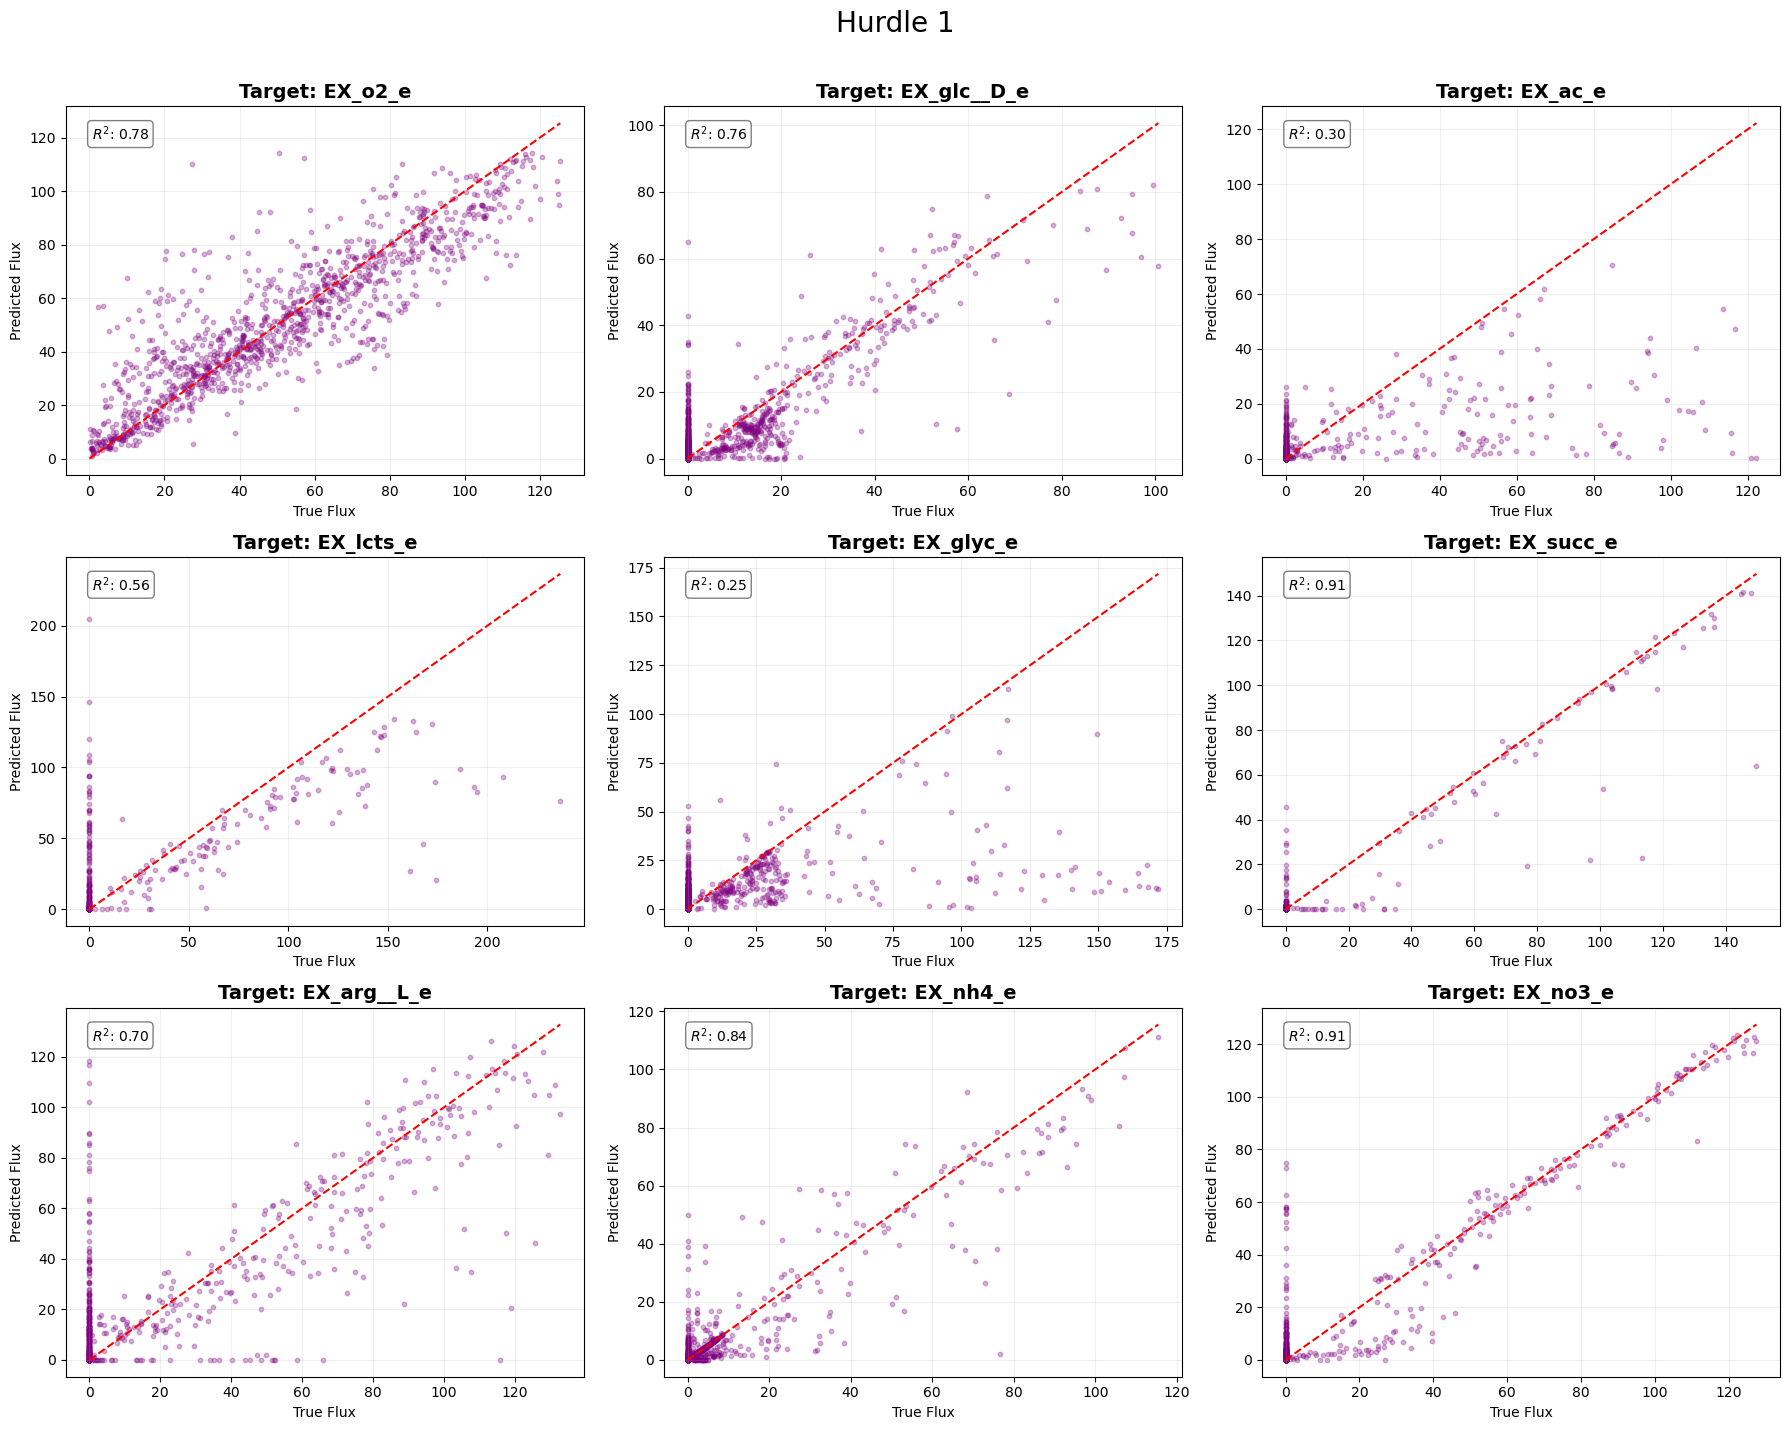

In [151]:
plot_all_targets_grid(Y_val_num, uptake_pred_val, color='purple', title='Hurdle 1')

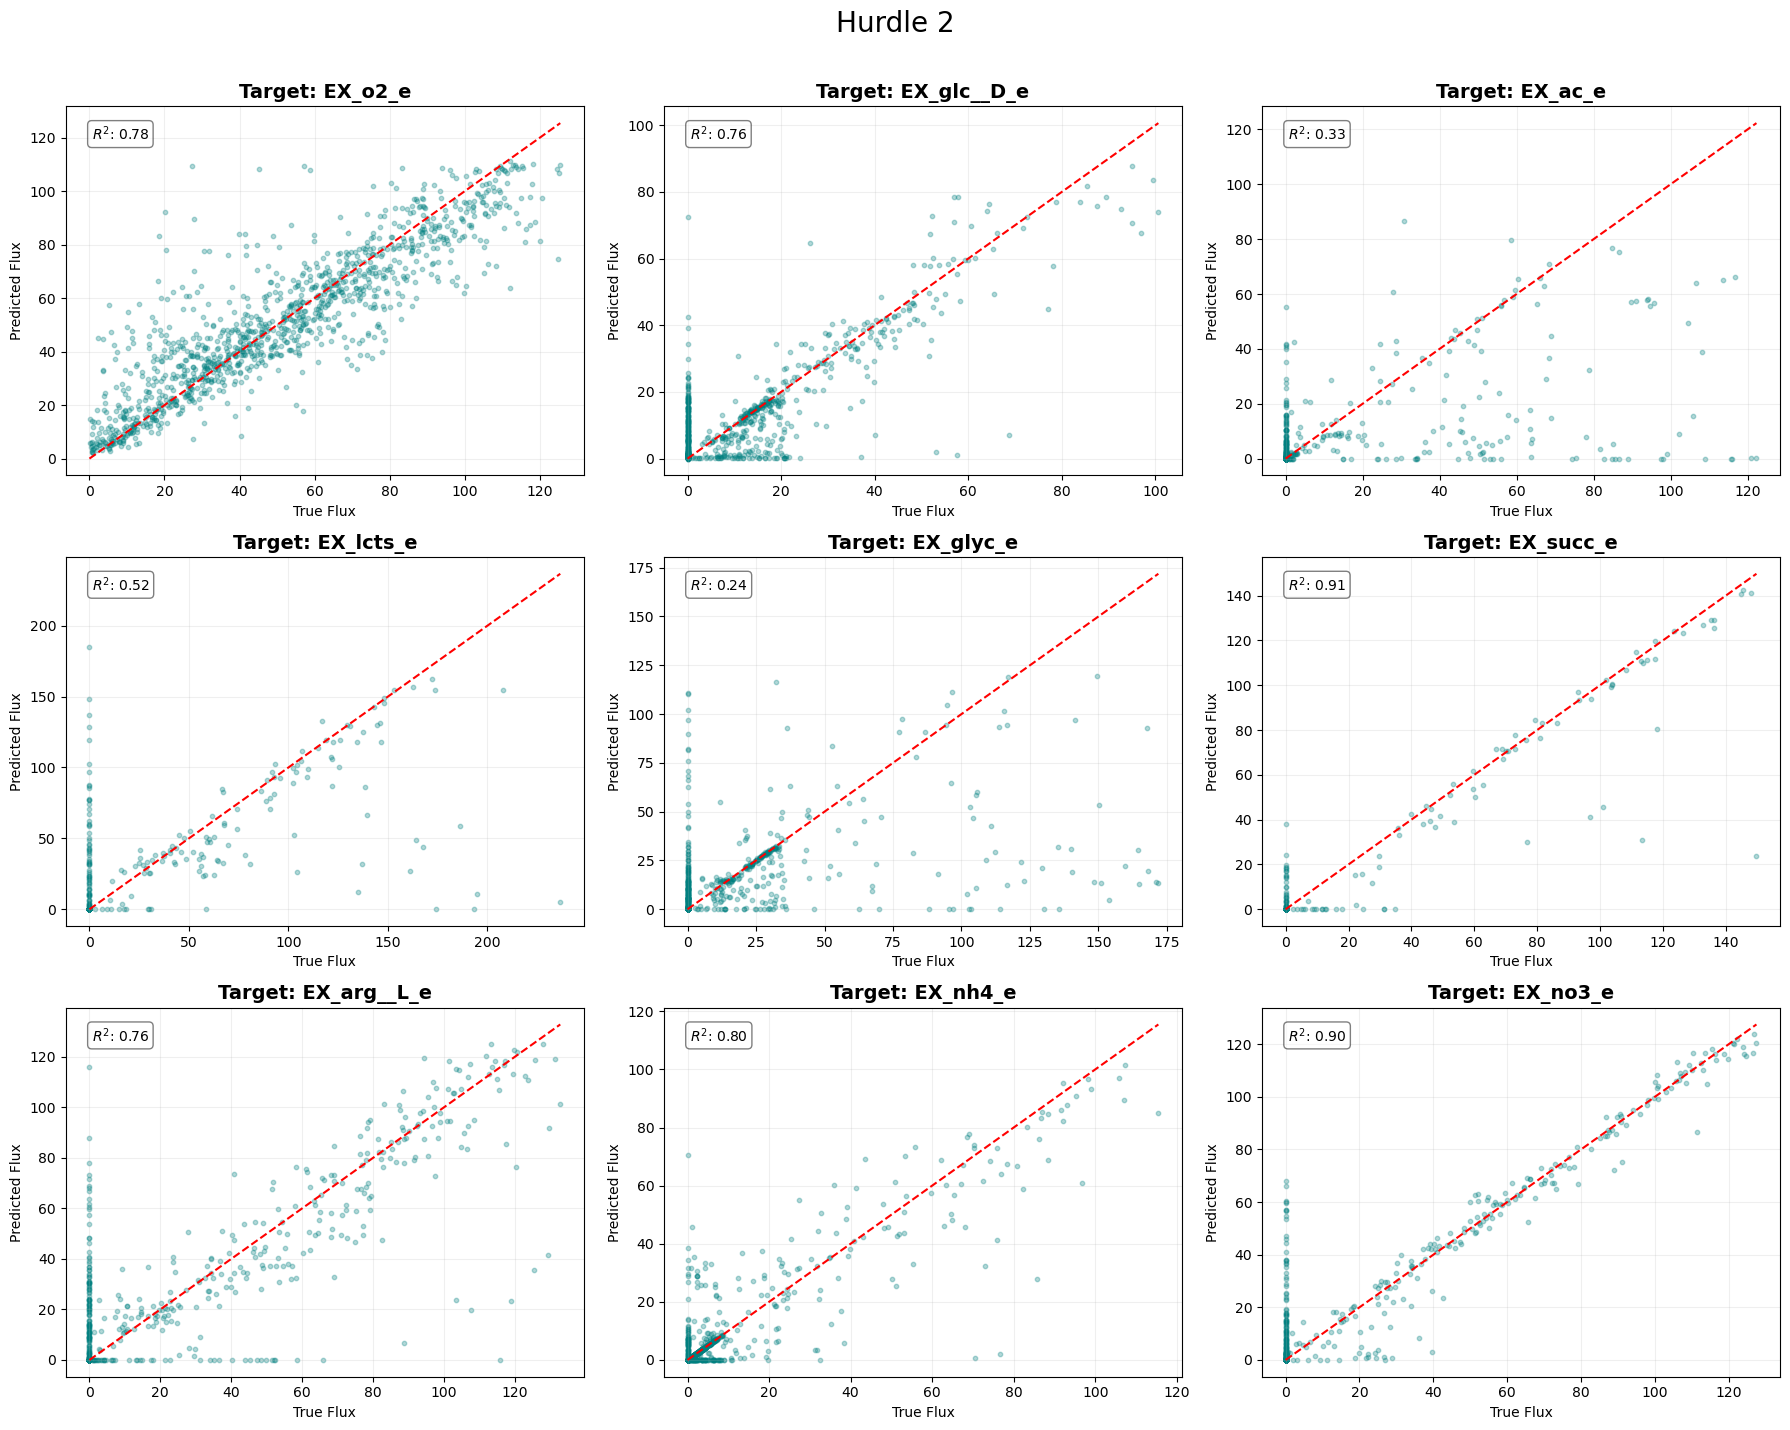

In [182]:
plot_all_targets_grid(Y_val_num, uptake_pred_val2, color='teal', title='Hurdle 2')

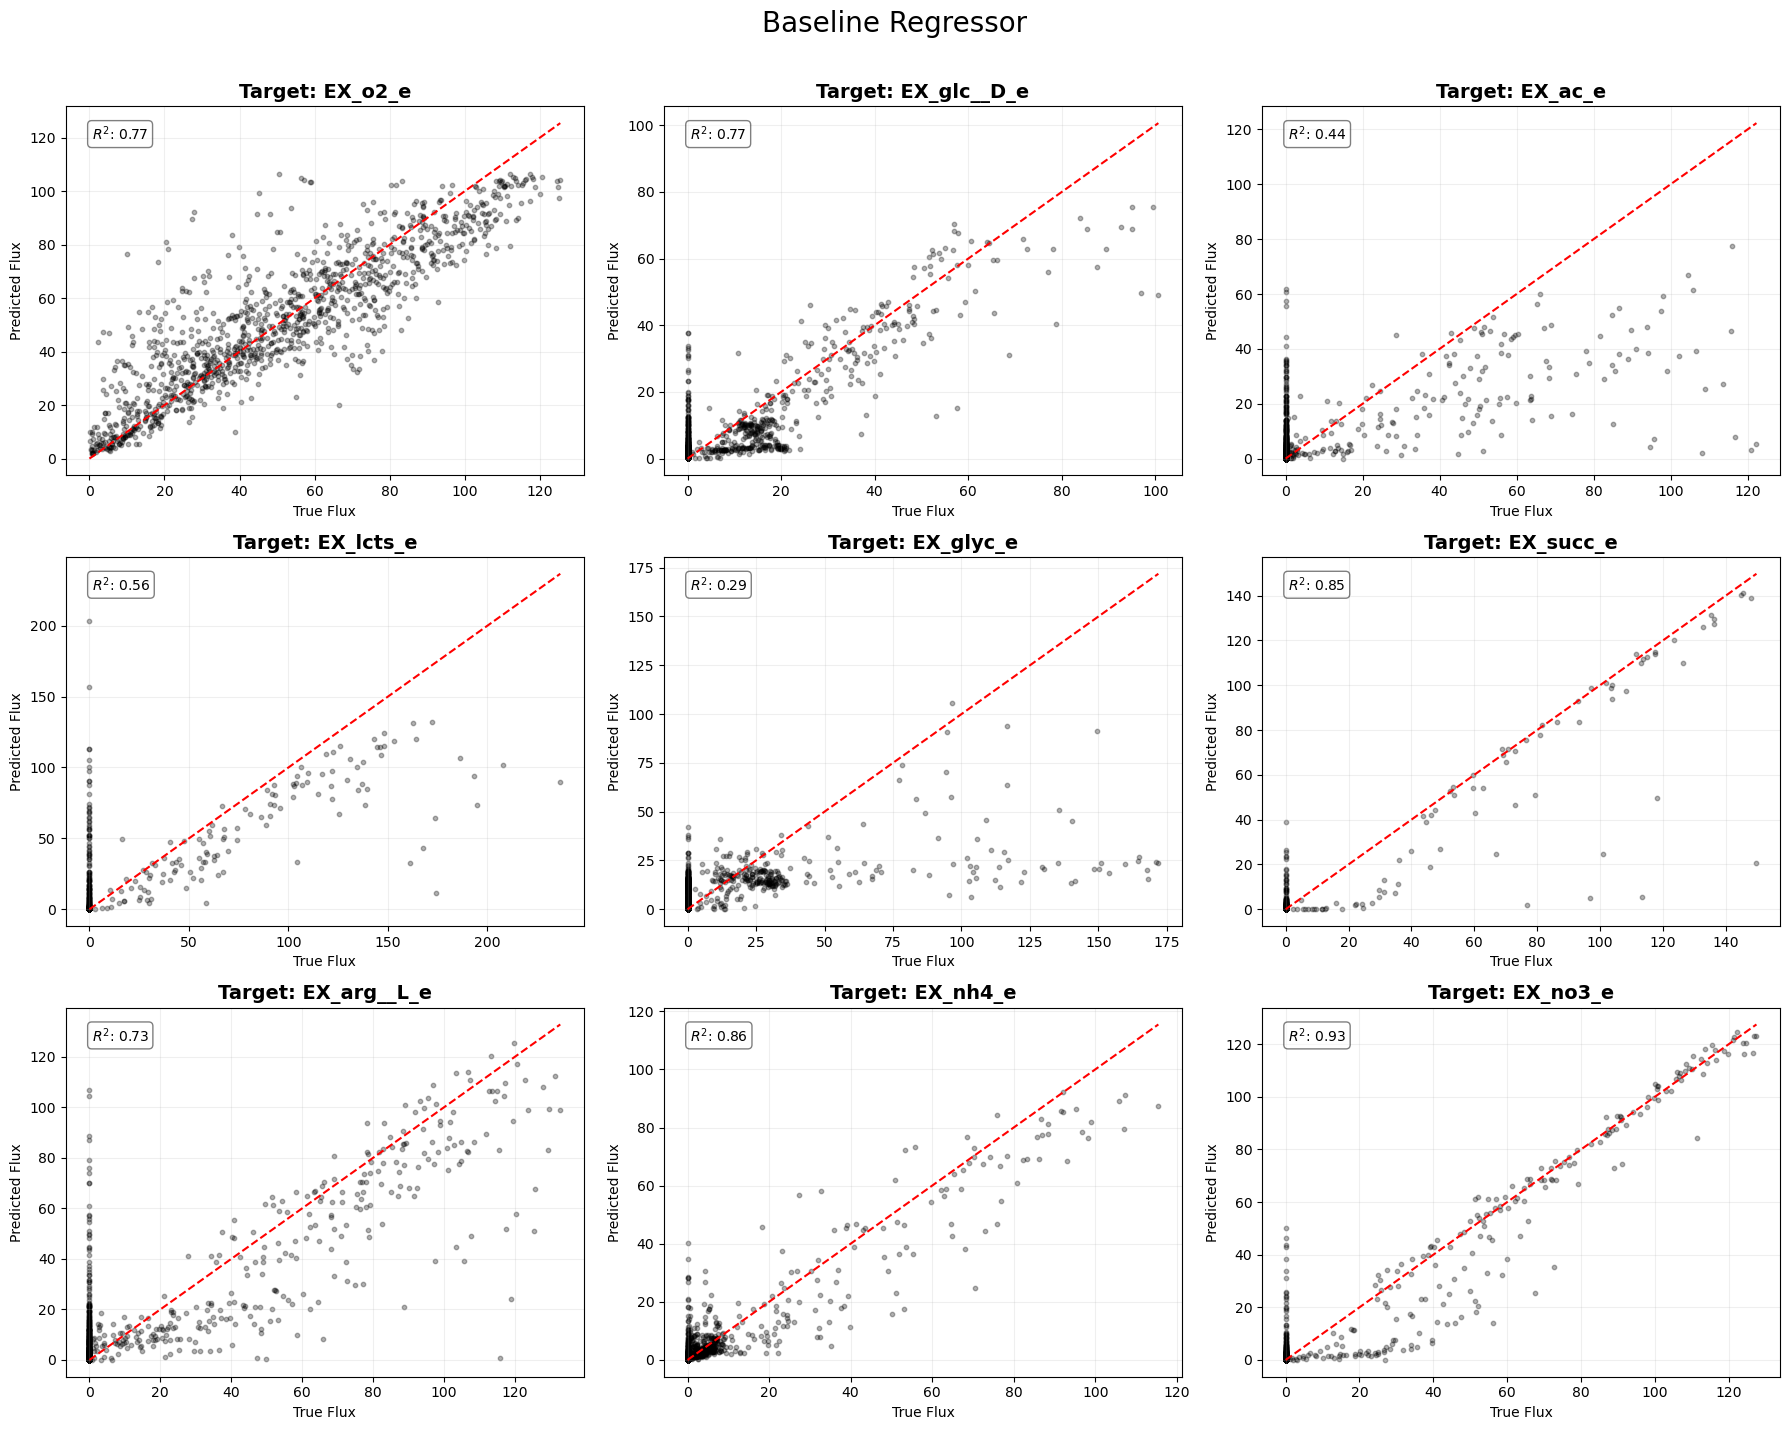

In [157]:
plot_all_targets_grid(Y_val_num, Y_pred_val_base, title='Baseline Regressor', color='black')

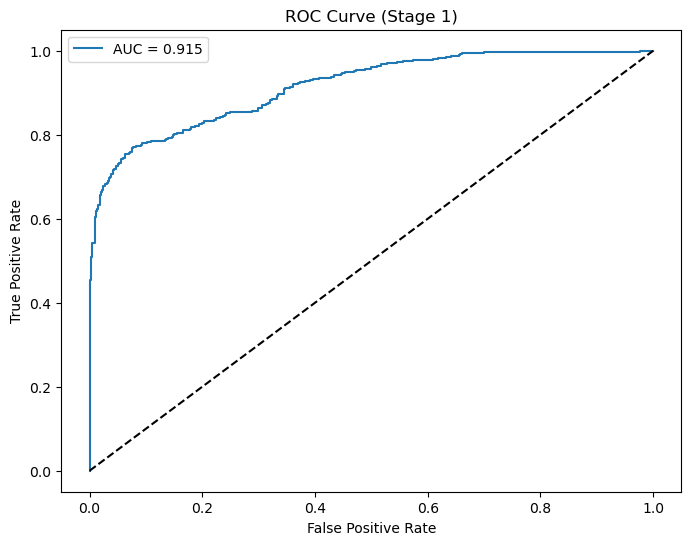

In [206]:
proba = binary_clf.predict_proba(X_val)

# get index of "carbon" class
carbon_label = le_type.transform(["carbon"])[0]
carbon_idx = list(binary_clf.classes_).index(carbon_label)

y_score = proba[:, carbon_idx]
y_true = (Y_val_type == carbon_label).astype(int)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Stage 1)")
plt.legend()
plt.show()

In [193]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

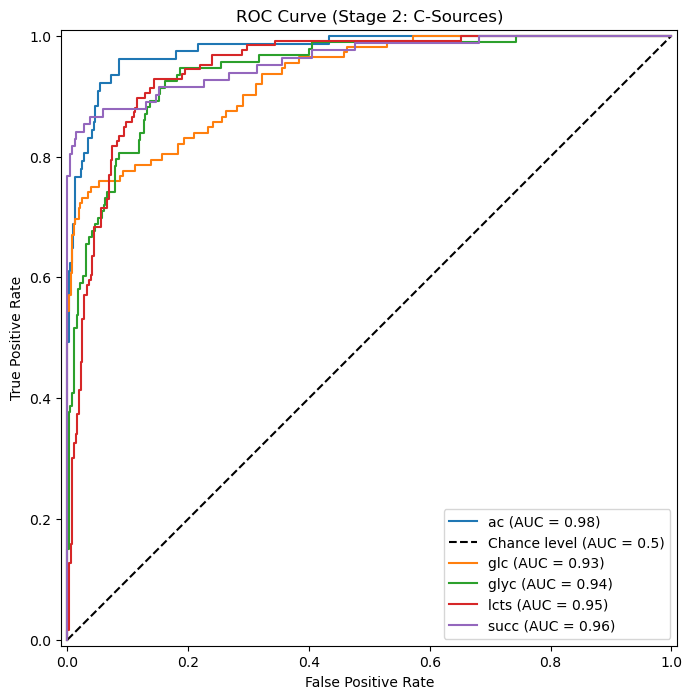

In [203]:
y_score = carbon_clf.predict_proba(X_val_c)
classes = np.arange(len(le_carbon.classes_))
y_onehot = label_binarize(Y_val_c_enc, classes=classes)

fig, ax = plt.subplots(figsize=(8, 8))

for class_id, class_name in enumerate(le_carbon.classes_):
    RocCurveDisplay.from_predictions(
        y_onehot[:, class_id],
        y_score[:, class_id],
        name=class_name,
        ax=ax,
        plot_chance_level=(class_id == 0),
    )

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve (Stage 2: C-Sources)"
)

plt.show()

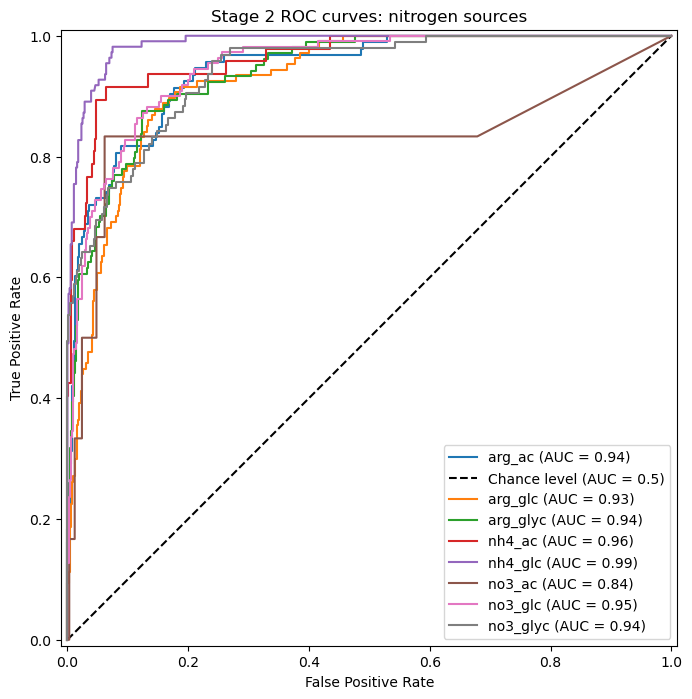

In [204]:
y_score = nitrogen_clf.predict_proba(X_val_n)
classes = np.arange(len(le_nitrogen.classes_))
y_onehot = label_binarize(Y_val_n_enc, classes=classes)

fig, ax = plt.subplots(figsize=(8, 8))

for class_id, class_name in enumerate(le_nitrogen.classes_):
    RocCurveDisplay.from_predictions(
        y_onehot[:, class_id],
        y_score[:, class_id],
        name=class_name,
        ax=ax,
        plot_chance_level=(class_id == 0),
    )

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Stage 2 ROC curves: nitrogen sources"
)

plt.show()